In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error
from sklearn.feature_selection import mutual_info_regression

pd.set_option("display.max_columns", None)

In [32]:
df = pd.read_csv("../data/raw/hour.csv")
df["dteday"] = pd.to_datetime(df["dteday"])
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [33]:
SPLIT_RATIO = 0.8

In [35]:
def build_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().sort_values("datetime").reset_index(drop=True)
    
    # Short-term momentum
    for lag in [1, 2, 3]:
        df[f"cnt_lag_{lag}"] = df["cnt"].shift(lag)
    
    # Morning-to-afternoon peak correlation
    for lag in [8, 9, 10]:
        df[f"cnt_lag_{lag}"] = df["cnt"].shift(lag)
    
    # Same hour yesterday and last week
    for lag in [24, 168]:
        df[f"cnt_lag_{lag}"] = df["cnt"].shift(lag)
    
    # Rolling averages (shift(1) to avoid leakage)
    df["cnt_rolling_mean_24"]  = df["cnt"].shift(1).rolling(24).mean()
    df["cnt_rolling_mean_168"] = df["cnt"].shift(1).rolling(168).mean()
    
    return df

In [36]:
def build_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # Cyclic encoding for hour and month
    df["hr_sin"]   = np.sin(2 * np.pi * df["hr"]   / 24)
    df["hr_cos"]   = np.cos(2 * np.pi * df["hr"]   / 24)
    df["mnth_sin"] = np.sin(2 * np.pi * df["mnth"] / 12)
    df["mnth_cos"] = np.cos(2 * np.pi * df["mnth"] / 12)
    
    # Regime separation: weekday vs weekend hourly patterns
    df["hr_workday"] = df["hr"] * df["workingday"]
    df["hr_weekend"] = df["hr"] * (1 - df["workingday"])
    
    # Season interaction
    df["hr_x_season"] = df["hr"] * df["season"]
    
    # Drop redundant feature
    df.drop(columns=["atemp"], inplace=True)
    
    return df

In [37]:
# 1. Build datetime column on full df
df["datetime"] = pd.to_datetime(df["dteday"]) + pd.to_timedelta(df["hr"], unit="h")

# 2. Lag features on full df BEFORE splitting
df = build_lag_features(df)

# 3. Calendar features and split
cutoff = df["dteday"].quantile(SPLIT_RATIO)
train = df[df["dteday"] <= cutoff].copy()
val   = df[df["dteday"] >  cutoff].copy()

train = build_calendar_features(train)
val   = build_calendar_features(val)

# 4. Drop NaN rows only from train
train = train.dropna()

print(f"Train: {len(train):,} rows")
print(f"Val:   {len(val):,} rows")

Train: 13,747 rows
Val:   3,464 rows


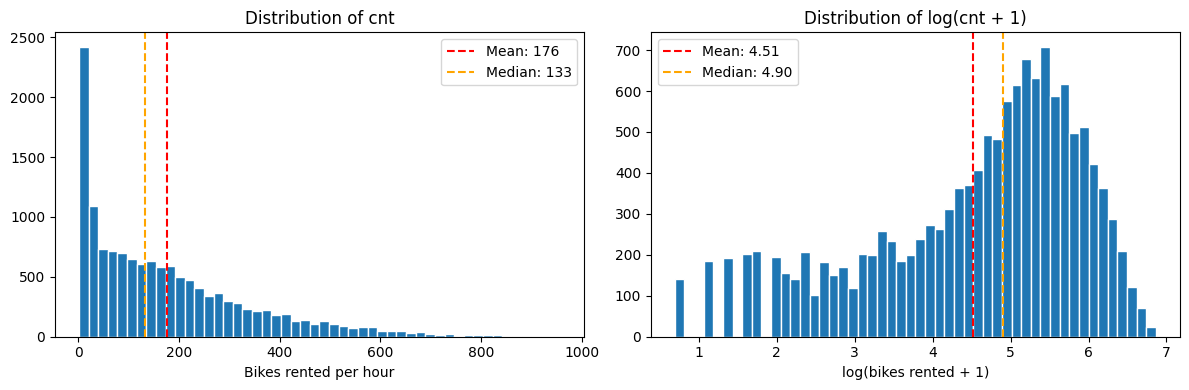

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# cnt directo
axes[0].hist(train["cnt"], bins=50, edgecolor="white")
axes[0].axvline(train["cnt"].mean(), color="red", linestyle="--", label=f"Mean: {train['cnt'].mean():.0f}")
axes[0].axvline(train["cnt"].median(), color="orange", linestyle="--", label=f"Median: {train['cnt'].median():.0f}")
axes[0].set_title("Distribution of cnt")
axes[0].set_xlabel("Bikes rented per hour")
axes[0].legend()

# log(cnt + 1)
train["log_cnt"] = np.log1p(train["cnt"])
val["log_cnt"]   = np.log1p(val["cnt"])

axes[1].hist(train["log_cnt"], bins=50, edgecolor="white")
axes[1].axvline(train["log_cnt"].mean(), color="red", linestyle="--", label=f"Mean: {train['log_cnt'].mean():.2f}")
axes[1].axvline(train["log_cnt"].median(), color="orange", linestyle="--", label=f"Median: {train['log_cnt'].median():.2f}")
axes[1].set_title("Distribution of log(cnt + 1)")
axes[1].set_xlabel("log(bikes rented + 1)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
FEATURES = [
    # Calendar
    "hr_sin", "hr_cos", "mnth_sin", "mnth_cos",
    "hr_workday", "hr_weekend", "hr_x_season",
    # Context
    "season", "yr", "holiday", "workingday", "weathersit",
    "temp", "hum", "windspeed",
    # Lags
    "cnt_lag_1", "cnt_lag_2", "cnt_lag_3",
    "cnt_lag_8", "cnt_lag_9", "cnt_lag_10",
    "cnt_lag_24", "cnt_lag_168",
    "cnt_rolling_mean_24", "cnt_rolling_mean_168",
]

X_train, X_val = train[FEATURES], val[FEATURES]

rf_cnt = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_cnt.fit(X_train, train["cnt"])

rf_log = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_log.fit(X_train, train["log_cnt"])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [55]:
pred_cnt = rf_cnt.predict(X_val)
pred_log = np.expm1(rf_log.predict(X_val))  # revertimos log con expm1

def evaluate(y_true, y_pred, label):
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    rmsle = np.sqrt(mean_squared_log_error(y_true, np.clip(y_pred, 0, None)))
    r2    = r2_score(y_true, y_pred)
    print(f"{label}")
    print(f"  RMSE:  {rmse:.2f}")
    print(f"  RMSLE: {rmsle:.4f}")
    print(f"  R²:    {r2:.4f}")
    print()

evaluate(val["cnt"], pred_cnt, "RF trained on cnt")
evaluate(val["cnt"], pred_log, "RF trained on log(cnt)")

RF trained on cnt
  RMSE:  81.56
  RMSLE: 0.4984
  R²:    0.8629

RF trained on log(cnt)
  RMSE:  72.97
  RMSLE: 0.3634
  R²:    0.8902



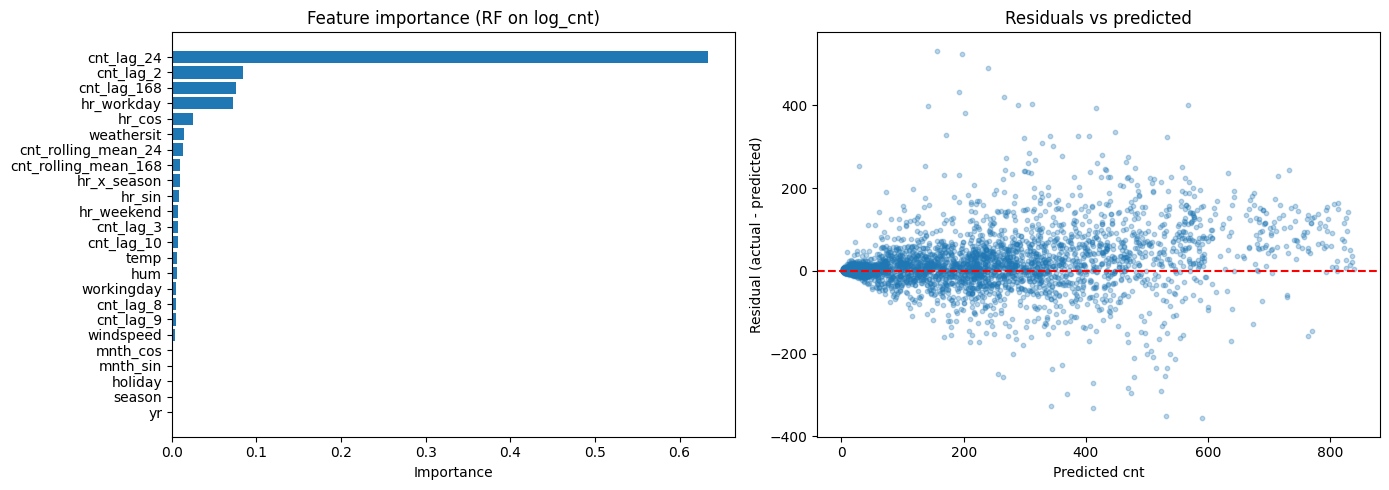

In [56]:
importance_df = pd.DataFrame({
    "feature":   FEATURES,
    "importance": rf_log.feature_importances_
}).sort_values("importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
axes[0].barh(importance_df["feature"], importance_df["importance"])
axes[0].invert_yaxis()
axes[0].set_title("Feature importance (RF on log_cnt)")
axes[0].set_xlabel("Importance")

# Residuals vs predicted
residuals = val["cnt"] - pred_log
axes[1].scatter(pred_log, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals vs predicted")
axes[1].set_xlabel("Predicted cnt")
axes[1].set_ylabel("Residual (actual - predicted)")

plt.tight_layout()
plt.show()

In [59]:
FEATURES_NO_LAG1 = [f for f in FEATURES if f != "cnt_lag_1"]

X_train_nl = train[FEATURES_NO_LAG1]
X_val_nl   = val[FEATURES_NO_LAG1]

rf_log_nl = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_log_nl.fit(X_train_nl, train["log_cnt"])

pred_log_nl = np.expm1(rf_log_nl.predict(X_val_nl))

evaluate(val["cnt"], pred_log,    "RF log(cnt) — with cnt_lag_1")
evaluate(val["cnt"], pred_log_nl, "RF log(cnt) — without cnt_lag_1")

RF log(cnt) — with cnt_lag_1
  RMSE:  72.97
  RMSLE: 0.3634
  R²:    0.8902

RF log(cnt) — without cnt_lag_1
  RMSE:  72.97
  RMSLE: 0.3634
  R²:    0.8902



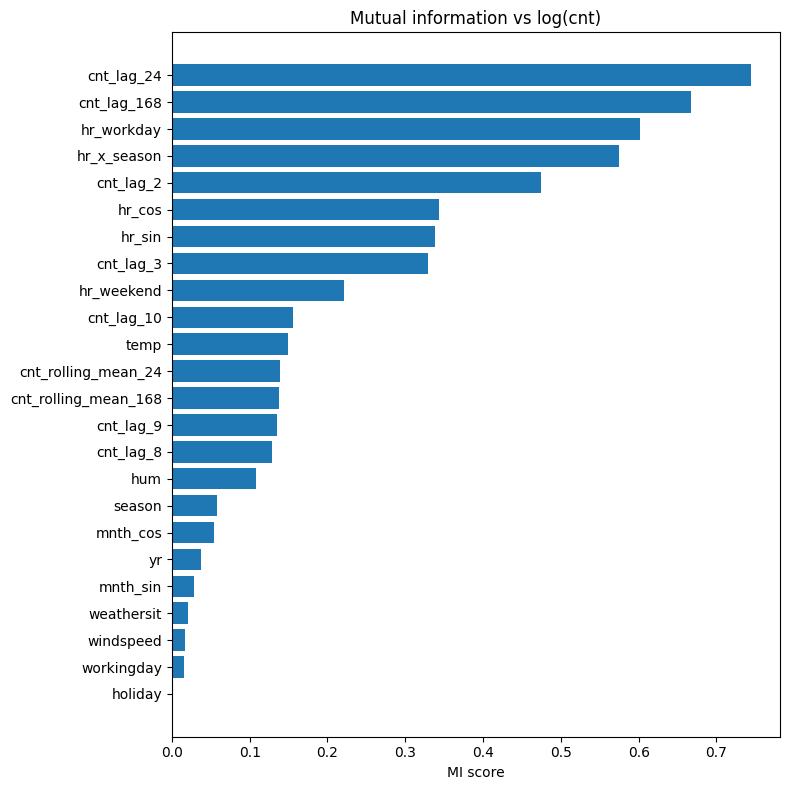

In [60]:
mi_scores = mutual_info_regression(
    X_train.fillna(0),
    train["log_cnt"],
    random_state=42
)

mi_df = pd.DataFrame({
    "feature":  FEATURES,
    "mi_score": mi_scores
}).sort_values("mi_score", ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(mi_df["feature"], mi_df["mi_score"])
ax.invert_yaxis()
ax.set_title("Mutual information vs log(cnt)")
ax.set_xlabel("MI score")
plt.tight_layout()
plt.show()